## <center> Аттестация. Практическое задание в Jupiter

В данном блоке вам предстоит решить задачу, которую автор когда-то решал на одном из своих собеседований.
Вам предоставлена таблица с данными (скачать файл можно на платформе) о ежедневной выработке энергии солнечными батареями. Информация в ней содержится в двух столбцах: 
* date - дата наблюдения
* cum_power - накопленная (кумулятивная) выработка энергии на указанный день

То есть перед вами классический пример временного ряда: числовой показатель, зависящий от времени. Давайте с ним поработаем.


In [1]:
import pandas as pd
import numpy as np

In [2]:
solar_power_data = pd.read_csv('data/solarpower.csv')

In [7]:
solar_power_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 664 entries, 0 to 663
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   date       664 non-null    object 
 1   cum_power  664 non-null    float64
dtypes: float64(1), object(1)
memory usage: 10.5+ KB


In [3]:
solar_power_data.head()

,date,cum_power
0,2017-01-01,20111.0
1,2017-01-02,20112.0
2,2017-01-03,20115.0
3,2017-01-04,20117.0
4,2017-01-05,20119.0


1. В нашем временном ряде есть несколько пропусков, они обозначены числом -1. Заполните пропуски средним арифметическим между двумя соседними наблюдениями: </p>
    $$x^*_i  = \frac{x_{i-1} - x_{i+1}}{2}$$ 
    
Совет: проще всего будет сделать это, используя цикл по индексам элементов столбца cum_power, но вы можете предложить более изящное решение.


In [24]:
solar_power_data['date'] = pd.to_datetime(solar_power_data['date']) 

# Заменяем значения -1, средним значением, рассчитаным за предыдущий и последующий день.
mask = solar_power_data['cum_power'] == -1
solar_power_data.loc[mask, 'cum_power'] = ( 
        solar_power_data.shift(periods=-1)['cum_power']
        + solar_power_data.shift(periods=1)['cum_power']
    ) / 2

2. Теперь, когда таблица заполнена, создайте столбец day_power - ежедневный прирост выработки солнечной энергии.

    После чего создайте данные о ежемесячной выработке энергии на каждый год. 
    
Совет: для того, чтобы выделить из даты год и месяц проще всего воспользоваться методом аксессора dt.to_period('M'), который позволяет выделять периоды, в данном случае 'М' - месяц.

In [36]:
# Создаем столбец, в котором рассчитываем дневной прирост энергии.
solar_power_data['day_power'] = solar_power_data['cum_power'] - solar_power_data.shift(periods=1)['cum_power']
solar_power_data['day_power'].fillna(0, inplace=True) 

# Создаем, в котором указываем год и месяц.
solar_power_data['year_month'] = solar_power_data['date'].dt.to_period('M')

# Группируем данные по месяцам.
month_power_df = solar_power_data.groupby('year_month')['day_power'].sum()

3. Постройте график временного ряда - ежемесячной выработки солнечной энергии. Не забудьте подписать оси и сам график.
Укажите в какие сезоны наблюдается подъем, а в какие спад?

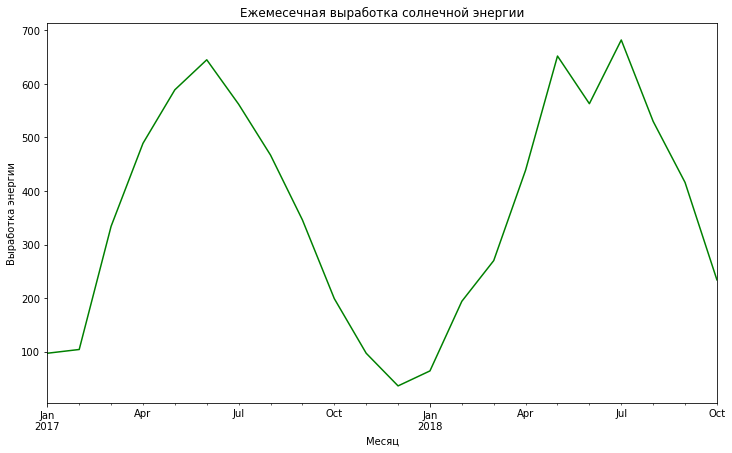

In [42]:
month_power_df.plot(
    figsize=(12, 7),
    title='Ежемесечная выработка солнечной энергии',
    xlabel='Месяц',
    ylabel='Выработка энергии',
    color='green'
);

Вывод:

На основании построенного графика, можно сделать вывод о сезонности выработке солнечной энергии, со снижением выработки в осенне-зимний период (наименьшия значения выработки соответствуют зимним месяцам), и увиличением - в весенне-летний период (пиковая выработка наблюдается в летние месяцы). 